In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/cosesmic/csv/final_ml_dataset_clean_random.csv"
)

In [ ]:
df.shape

(29899, 19)

In [ ]:
df.head()

,ASPECT_11,ELEVATION_11,SLOPE_11,PLAN_CURV_11,PROFILE_CURV_11,TWI_11,TRI_11,NDVI_11,LULC_11,PROXIMITY_ROADS_11,PROXIMITY_RIVERS_11,PROXIMITY_FAULTS_11,MAX_RAINFALL_11,MEAN_RAINFALL_11,MONSOON_RAINFALL_11,FLOW_ACC_11,label,X_COORD,Y_COORD
0,3.0,679.130005,0.276021,-0.016538,-0.008122,15.716049,7.545804,0.160194,30.0,0.000000,1.414214,2658.006836,529.694031,121.518135,258.144958,17.800678,1,401540.952,3261698.480
1,4.0,913.332825,0.632032,0.000268,-0.000074,5.646492,13.151764,0.295511,30.0,108.166534,16.000000,3178.442871,547.740418,118.726166,252.454834,8.681055,1,400035.083,3261801.147
2,8.0,721.089966,0.681697,-0.008121,0.000211,7.185718,14.802107,0.268077,10.0,60.000000,8.062258,1397.175781,529.694031,121.518135,258.144958,10.322898,1,403318.553,3261938.765
3,3.0,758.113342,0.561121,-0.002347,-0.000685,6.366368,11.326160,0.243862,30.0,240.000000,15.000000,2992.340332,529.694031,121.518135,258.144958,9.248116,1,400375.404,3262129.371
4,2.0,731.924133,0.589670,-0.007241,0.001289,7.196071,12.147046,0.338092,30.0,108.166534,6.708204,1855.397583,529.694031,121.518135,258.144958,10.140306,1,402218.711,3262123.997


In [ ]:
features = [
    col for col in df.columns
    if col not in [
        'X_COORD',
        'Y_COORD',
        'label'
    ]
]

In [ ]:
X = df[features]
y = df['label']

In [ ]:
print(X.columns.tolist())

['ASPECT_11', 'ELEVATION_11', 'SLOPE_11', 'PLAN_CURV_11', 'PROFILE_CURV_11', 'TWI_11', 'TRI_11', 'NDVI_11', 'LULC_11', 'PROXIMITY_ROADS_11', 'PROXIMITY_RIVERS_11', 'PROXIMITY_FAULTS_11', 'MAX_RAINFALL_11', 'MEAN_RAINFALL_11', 'MONSOON_RAINFALL_11', 'FLOW_ACC_11']


In [ ]:
def calculate_vif(df):

    vif_data = pd.DataFrame()

    vif_data["Feature"] = df.columns

    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]

    return vif_data.sort_values(
        by="VIF",
        ascending=False
    ).reset_index(drop=True)

In [ ]:
print(calculate_vif(X))

                Feature          VIF
0           FLOW_ACC_11  1078.940886
1      MEAN_RAINFALL_11   827.099366
2   MONSOON_RAINFALL_11   807.461546
3                TWI_11   557.084637
4       MAX_RAINFALL_11   207.339398
5              SLOPE_11    45.857172
6          ELEVATION_11    14.523922
7               NDVI_11     8.191971
8               LULC_11     5.398295
9             ASPECT_11     5.380243
10   PROXIMITY_ROADS_11     3.428007
11  PROXIMITY_RIVERS_11     2.896943
12  PROXIMITY_FAULTS_11     2.303896
13               TRI_11     1.323851
14      PROFILE_CURV_11     1.282616
15         PLAN_CURV_11     1.208138


In [ ]:
def reduce_multicollinearity(
    df,
    threshold=10.0,
    protected_features=None
):

    if protected_features is None:
        protected_features = []

    while True:

        vif_df = calculate_vif(df)

        print("\n--- Current VIF Scores ---")

        print(vif_df)

        highest_vif = vif_df.iloc[0]["VIF"]

        highest_feature = vif_df.iloc[0]["Feature"]

        if highest_vif > threshold:

            if highest_feature in protected_features:

                found_alternative = False

                for i in range(1, len(vif_df)):

                    next_feature = vif_df.iloc[i]["Feature"]

                    next_vif = vif_df.iloc[i]["VIF"]

                    if (
                        next_feature not in protected_features
                        and next_vif > threshold
                    ):

                        print(
                            f"Skipping protected feature "
                            f"'{highest_feature}' "
                            f"({highest_vif:.2f})"
                        )

                        print(
                            f"Dropping next highest culprit: "
                            f"'{next_feature}' "
                            f"({next_vif:.2f})"
                        )

                        df = df.drop(columns=[next_feature])

                        found_alternative = True

                        break

                if not found_alternative:

                    print(
                        "\nAll remaining features "
                        "above threshold are protected."
                    )

                    break

            else:

                print(
                    f"Dropping: '{highest_feature}' "
                    f"with VIF: {highest_vif:.2f}"
                )

                df = df.drop(columns=[highest_feature])

        else:

            print(
                f"\nSuccess! All features "
                f"below threshold {threshold}"
            )

            break

    return df


In [ ]:
critical_layers = ['ELEVATION_11']

In [ ]:
final_features_df = reduce_multicollinearity(X, threshold=10.0, protected_features=critical_layers)


--- Current VIF Scores ---
                Feature          VIF
0           FLOW_ACC_11  1078.940886
1      MEAN_RAINFALL_11   827.099366
2   MONSOON_RAINFALL_11   807.461546
3                TWI_11   557.084637
4       MAX_RAINFALL_11   207.339398
5              SLOPE_11    45.857172
6          ELEVATION_11    14.523922
7               NDVI_11     8.191971
8               LULC_11     5.398295
9             ASPECT_11     5.380243
10   PROXIMITY_ROADS_11     3.428007
11  PROXIMITY_RIVERS_11     2.896943
12  PROXIMITY_FAULTS_11     2.303896
13               TRI_11     1.323851
14      PROFILE_CURV_11     1.282616
15         PLAN_CURV_11     1.208138
Dropping: 'FLOW_ACC_11' with VIF: 1078.94

--- Current VIF Scores ---
                Feature         VIF
0   MONSOON_RAINFALL_11  785.252363
1      MEAN_RAINFALL_11  752.033431
2       MAX_RAINFALL_11  205.680972
3                TWI_11   14.664325
4          ELEVATION_11   14.289980
5              SLOPE_11   12.691404
6               NDVI_

In [ ]:
print(final_features_df.columns.tolist())

['ASPECT_11', 'ELEVATION_11', 'SLOPE_11', 'PLAN_CURV_11', 'PROFILE_CURV_11', 'TRI_11', 'NDVI_11', 'LULC_11', 'PROXIMITY_ROADS_11', 'PROXIMITY_RIVERS_11', 'PROXIMITY_FAULTS_11', 'MAX_RAINFALL_11']


In [ ]:
# ============================================================
# FINAL FEATURES
# ============================================================

features = final_features_df.columns.tolist()

X = df[features]

y = df['label']

In [ ]:
# ============================================================
# CREATE SPATIAL BLOCKS
# ============================================================

block_size = 5000   # 5 km

df['x_block'] = (
    df['X_COORD'] // block_size
).astype(int)

df['y_block'] = (
    df['Y_COORD'] // block_size
).astype(int)

df['spatial_block'] = (
    df['x_block'].astype(str)
    + "_"
    + df['y_block'].astype(str)
)

print(
    "\nTotal Spatial Blocks:",
    df['spatial_block'].nunique()
)



Total Spatial Blocks: 1898


In [ ]:
from sklearn.model_selection import (
    GroupKFold,
    cross_validate,
    RandomizedSearchCV
)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [ ]:
groups = df['spatial_block']
gkf = GroupKFold(n_splits=5)

In [ ]:
X.columns.tolist()

['ASPECT_11',
 'ELEVATION_11',
 'SLOPE_11',
 'PLAN_CURV_11',
 'PROFILE_CURV_11',
 'TRI_11',
 'NDVI_11',
 'LULC_11',
 'PROXIMITY_ROADS_11',
 'PROXIMITY_RIVERS_11',
 'PROXIMITY_FAULTS_11',
 'MAX_RAINFALL_11']

In [ ]:
models = {

    "Logistic Regression": Pipeline([

        ('scaler', StandardScaler()),

        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    "Support Vector Machine": Pipeline([

        ('scaler', StandardScaler()),

        ('model', SVC(
            probability=True,
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

In [ ]:
scoring = {
  'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}



BASELINE SPATIAL CROSS VALIDATION

MODEL: Logistic Regression
Accuracy : 0.8344
Precision: 0.8100
Recall   : 0.9001
F1 Score : 0.8526
ROC-AUC  : 0.9100
ROC STD  : 0.0154

Fold ROC Scores:
[0.8873 0.9211 0.9024 0.932  0.9071]


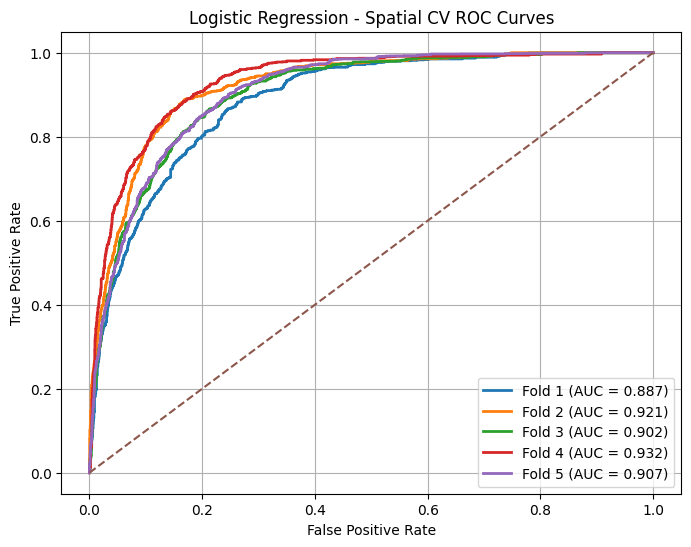


MODEL: Random Forest
Accuracy : 0.8838
Precision: 0.9353
Recall   : 0.8398
F1 Score : 0.8850
ROC-AUC  : 0.9533
ROC STD  : 0.0034

Fold ROC Scores:
[0.9543 0.9571 0.9488 0.9565 0.9499]


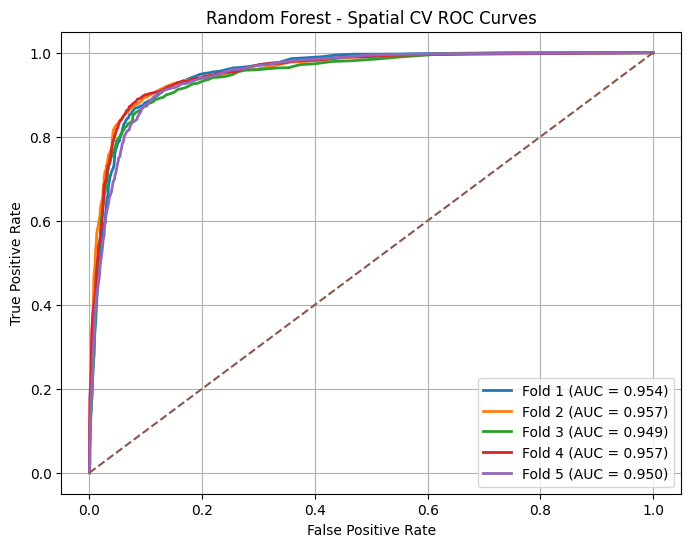


MODEL: Support Vector Machine
Accuracy : 0.8568
Precision: 0.8361
Recall   : 0.9091
F1 Score : 0.8710
ROC-AUC  : 0.9301
ROC STD  : 0.0081

Fold ROC Scores:
[0.9162 0.9357 0.9263 0.9389 0.9335]


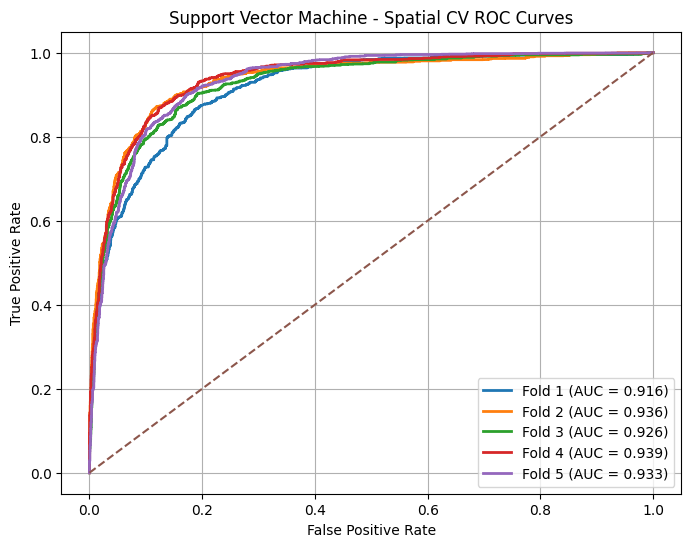


MODEL: XGBoost
Accuracy : 0.8859
Precision: 0.9272
Recall   : 0.8526
F1 Score : 0.8883
ROC-AUC  : 0.9539
ROC STD  : 0.0025

Fold ROC Scores:
[0.9539 0.958  0.9501 0.9544 0.953 ]


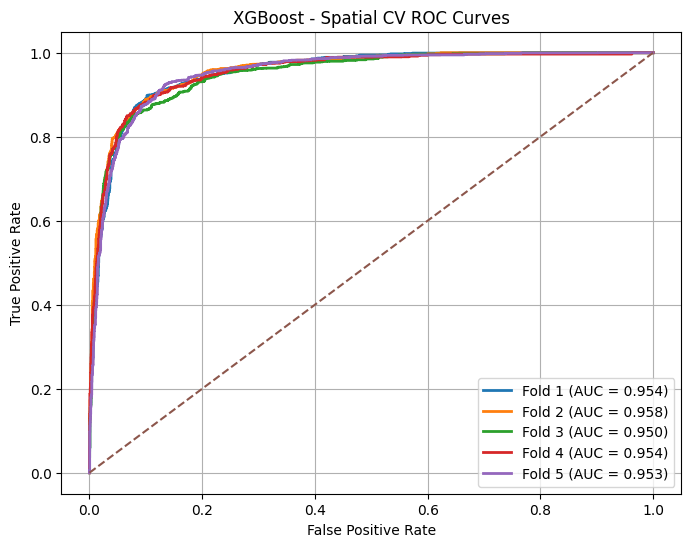


FINAL BASELINE SPATIAL CV RESULTS
                    Model  Accuracy  Precision    Recall  F1_Score   ROC_AUC  \
3                 XGBoost  0.885882   0.927174  0.852571  0.888288  0.953895   
1           Random Forest  0.883809   0.935348  0.839808  0.884990  0.953339   
2  Support Vector Machine  0.856751   0.836122  0.909109  0.871015  0.930120   
0     Logistic Regression  0.834409   0.809982  0.900075  0.852610  0.909965   

    ROC_STD  
3  0.002545  
1  0.003392  
2  0.008090  
0  0.015440  


In [ ]:
#  ============================================================
# BASELINE SPATIAL CROSS VALIDATION
# ============================================================

print("\n" + "="*60)
print("BASELINE SPATIAL CROSS VALIDATION")
print("="*60)

results = []

for name, model in models.items():
    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)

    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    plt.figure(figsize=(8,6))

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # ====================================================
        # TRAIN MODEL
        # ====================================================

        model.fit(X_train, y_train)

        # ====================================================
        # PREDICTIONS
        # ====================================================

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # ====================================================
        # METRICS
        # ====================================================

        accuracy_scores.append(
            accuracy_score(y_test, y_pred)
        )

        precision_scores.append(
            precision_score(y_test, y_pred)
        )

        recall_scores.append(
            recall_score(y_test, y_pred)
        )

        f1_scores.append(
            f1_score(y_test, y_pred)
        )

        auc = roc_auc_score(y_test, y_prob)

        auc_scores.append(auc)

        # ====================================================
        # ROC CURVE
        # ====================================================

        fpr, tpr, _ = roc_curve(y_test, y_prob)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f'Fold {fold+1} (AUC = {auc:.3f})'
        )

    # ========================================================
    # FINAL METRICS
    # ========================================================

    accuracy = np.mean(accuracy_scores)
    precision = np.mean(precision_scores)
    recall = np.mean(recall_scores)
    f1 = np.mean(f1_scores)
    auc_mean = np.mean(auc_scores)
    auc_std = np.std(auc_scores)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc_mean:.4f}")
    print(f"ROC STD  : {auc_std:.4f}")
    print("\nFold ROC Scores:")
    print(np.round(auc_scores, 4))

    # ========================================================
    # ROC PLOT SETTINGS
    # ========================================================

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - Spatial CV ROC Curves")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": auc_mean,
        "ROC_STD": auc_std
    })

# ============================================================
# FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

print("\n" + "="*60)
print("FINAL BASELINE SPATIAL CV RESULTS")
print("="*60)
print(results_df)

In [ ]:
rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

In [ ]:
rf_random = RandomizedSearchCV(

    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=gkf,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

rf_random.fit(X, y, groups=groups)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
best_rf = rf_random.best_estimator_
print("\nBest RF Parameters:")
print(rf_random.best_params_)


Best RF Parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [ ]:
from rasterio.windows import Window

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
best_rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    max_depth=None,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# ============================================================
# RF FINAL SPATIAL CV
# ============================================================

rf_cv_results = cross_validate(
    estimator=best_rf,
    X=X,
    y=y,
    groups=groups,
    cv=gkf,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
print("\n" + "="*60)
print("FINAL RANDOM FOREST SPATIAL CV RESULTS")
print("="*60)
print(f"Accuracy : {rf_cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {rf_cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {rf_cv_results['test_recall'].mean():.4f}")
print(f"F1 Score : {rf_cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC  : {rf_cv_results['test_roc_auc'].mean():.4f}")
print(f"ROC STD  : {rf_cv_results['test_roc_auc'].std():.4f}")
print("\nFold ROC Scores:")
print(np.round(rf_cv_results['test_roc_auc'], 4))

# print(f"Mean ROC-AUC: {rf_cv_results['test_roc_auc'].mean():.4f}")
# print(f"ROC STD     : {rf_cv_results['test_roc_auc'].std():.4f}")
# print("\nFold ROC Scores:")
# print(rf_cv_results['test_roc_auc'])


FINAL RANDOM FOREST SPATIAL CV RESULTS
Accuracy : 0.8871
Precision: 0.9332
Recall   : 0.8487
F1 Score : 0.8889
ROC-AUC  : 0.9548
ROC STD  : 0.0035

Fold ROC Scores:
[0.9563 0.9583 0.9508 0.9583 0.9506]



RANDOM FOREST FEATURE IMPORTANCE
                Feature  Importance
8    PROXIMITY_ROADS_11    0.440738
1          ELEVATION_11    0.141800
6               NDVI_11    0.097999
9   PROXIMITY_RIVERS_11    0.072707
11      MAX_RAINFALL_11    0.043676
2              SLOPE_11    0.036594
5                TRI_11    0.035613
7               LULC_11    0.032294
10  PROXIMITY_FAULTS_11    0.030290
4       PROFILE_CURV_11    0.027600
3          PLAN_CURV_11    0.026390
0             ASPECT_11    0.014298


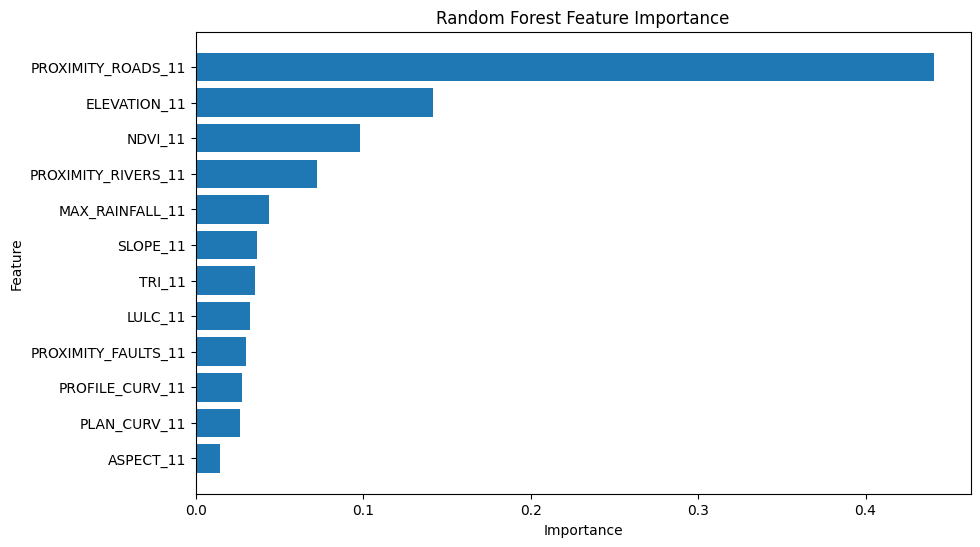

In [ ]:
# ============================================================
# RF FEATURE IMPORTANCE
# ============================================================

best_rf.fit(X, y)
rf_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n" + "="*60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*60)
print(rf_importance_df)

plt.figure(figsize=(10,6))

plt.barh(
    rf_importance_df['Feature'],
    rf_importance_df['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

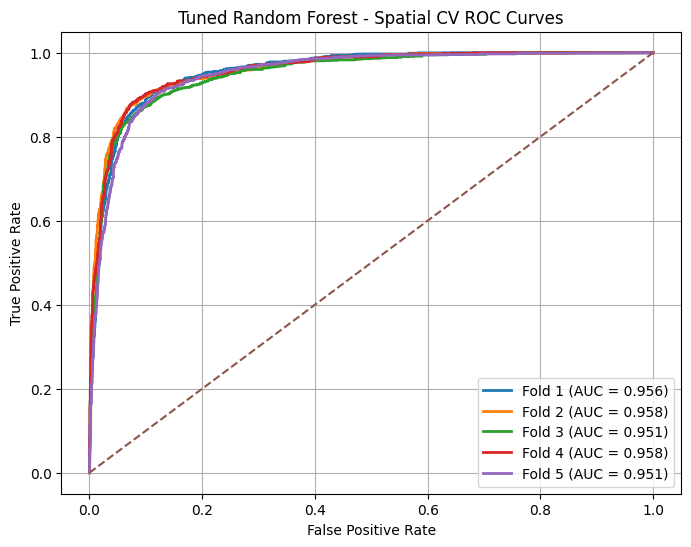

In [ ]:
plt.figure(figsize=(8,6))

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    best_rf.fit(X_train, y_train)
    y_prob = best_rf.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'Fold {fold+1} (AUC = {auc:.3f})'
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Random Forest - Spatial CV ROC Curves")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
xgb_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=gkf,
    random_state=42,
    verbose=2,
    n_jobs=-1
)



In [ ]:
print("\n" + "="*60)
print("TUNING XGBOOST")
print("="*60)

xgb_random.fit(X, y, groups=groups)
best_xgb = xgb_random.best_estimator_

print("\nBest XGB Parameters:")
print(xgb_random.best_params_)


TUNING XGBOOST
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGB Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}


In [ ]:
best_xgb = XGBClassifier(
    subsample=0.7,
    n_estimators=500,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_cv_results = cross_validate(
    estimator=best_xgb,
    X=X,
    y=y,
    groups=groups,
    cv=gkf,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
print("\n" + "="*60)
print("FINAL XGBOOST SPATIAL CV RESULTS")
print("="*60)
# print(f"Mean ROC-AUC: {xgb_cv_results['test_roc_auc'].mean():.4f}")
# print(f"ROC STD     : {xgb_cv_results['test_roc_auc'].std():.4f}")
# print("\nFold ROC Scores:")
# print(xgb_cv_results['test_roc_auc'])

print(f"Accuracy : {xgb_cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {xgb_cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {xgb_cv_results['test_recall'].mean():.4f}")
print(f"F1 Score : {xgb_cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC  : {xgb_cv_results['test_roc_auc'].mean():.4f}")
print(f"ROC STD  : {xgb_cv_results['test_roc_auc'].std():.4f}")
print("\nFold ROC Scores:")
print(np.round(xgb_cv_results['test_roc_auc'], 4))



FINAL XGBOOST SPATIAL CV RESULTS
Accuracy : 0.8951
Precision: 0.9196
Recall   : 0.8799
F1 Score : 0.8993
ROC-AUC  : 0.9582
ROC STD  : 0.0026

Fold ROC Scores:
[0.9571 0.9618 0.9567 0.9605 0.9549]



XGBOOST FEATURE IMPORTANCE
                Feature  Importance
8    PROXIMITY_ROADS_11    0.550221
1          ELEVATION_11    0.086348
6               NDVI_11    0.084358
9   PROXIMITY_RIVERS_11    0.065239
7               LULC_11    0.049025
2              SLOPE_11    0.035092
11      MAX_RAINFALL_11    0.030701
5                TRI_11    0.025522
0             ASPECT_11    0.021107
10  PROXIMITY_FAULTS_11    0.018152
4       PROFILE_CURV_11    0.017430
3          PLAN_CURV_11    0.016806


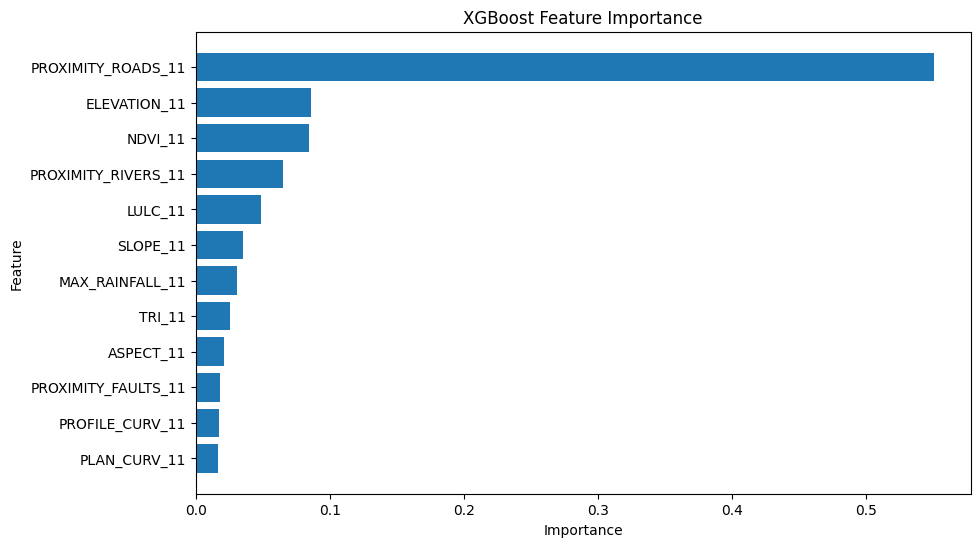

In [ ]:
# ============================================================
# XGB FEATURE IMPORTANCE
# ============================================================

best_xgb.fit(X, y)
xgb_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_xgb.feature_importances_
})

xgb_importance_df = xgb_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n" + "="*60)
print("XGBOOST FEATURE IMPORTANCE")
print("="*60)
print(xgb_importance_df)

plt.figure(figsize=(10,6))
plt.barh(
    xgb_importance_df['Feature'],
    xgb_importance_df['Importance']
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

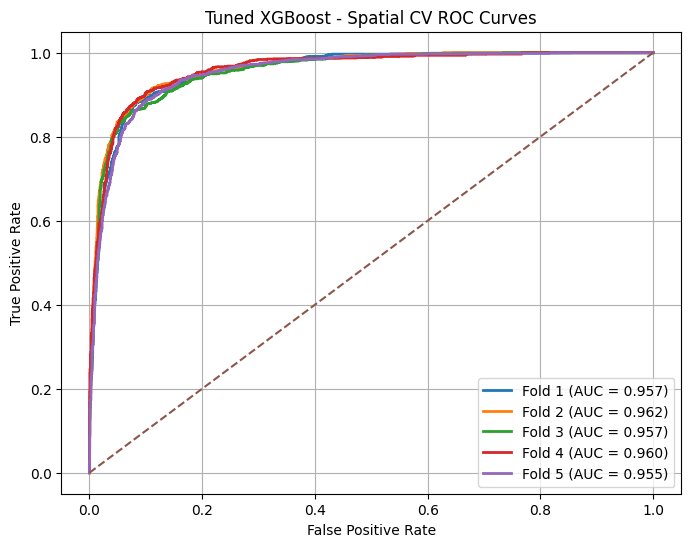

In [ ]:
# ============================================================
# XGBOOST ROC CURVES
# ============================================================

plt.figure(figsize=(8,6))

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]

    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]

    y_test = y.iloc[test_idx]

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    best_xgb.fit(X_train, y_train)

    # ========================================================
    # PREDICTION PROBABILITIES
    # ========================================================

    y_prob = best_xgb.predict_proba(X_test)[:,1]

    # ========================================================
    # ROC + AUC
    # ========================================================

    auc = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # ========================================================
    # PLOT
    # ========================================================

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'Fold {fold+1} (AUC = {auc:.3f})'
    )

# ============================================================
# RANDOM BASELINE
# ============================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

# ============================================================
# LABELS
# ============================================================

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Tuned XGBoost - Spatial CV ROC Curves")

plt.legend(loc='lower right')

plt.grid(True)

plt.show()

In [ ]:
best_rf.fit(X, y)
best_xgb.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
import rasterio

In [ ]:


['ASPECT_11',
 'ELEVATION_11',
 'SLOPE_11',
 'PLAN_CURV_11',
 'PROFILE_CURV_11',
 'TRI_11',
 'NDVI_11',
 'LULC_11',
 'PROXIMITY_ROADS_11',
 'PROXIMITY_RIVERS_11',
 'PROXIMITY_FAULTS_11',
 'MAX_RAINFALL_11']

['ASPECT_11',
 'ELEVATION_11',
 'SLOPE_11',
 'PLAN_CURV_11',
 'PROFILE_CURV_11',
 'TRI_11',
 'NDVI_11',
 'LULC_11',
 'PROXIMITY_ROADS_11',
 'PROXIMITY_RIVERS_11',
 'PROXIMITY_FAULTS_11',
 'MAX_RAINFALL_11']

In [ ]:
raster_path="/content/drive/MyDrive/cosesmic/layers/rasters/"

In [ ]:
models = {
    "RF": best_rf,
    "XGB": best_xgb
}

In [ ]:
raster_paths = {
    "Aspect": raster_path + "aligned_Aspect.tif",
    "Elevation": raster_path + "aligned_Elevation.tif",
    "Slope": raster_path + "aligned_Slope.tif",
    "Plan Curvature": raster_path + "aligned_Plan_Curvature.tif",
    "Profile Curvature": raster_path + "aligned_Profile_Curvature.tif",
    "TRI": raster_path + "aligned_TRI.tif",
    "NDVI": raster_path + "aligned_NDVI.tif",
    "LULC": raster_path + "aligned_LULC.tif",
    "Proximity_Road": raster_path + "aligned_Proximity_Road.tif",
    "Proximity_Rivers": raster_path + "aligned_Proximity_Rivers.tif",
    "Proximity_Faults": raster_path + "aligned_Proximity_Faults.tif",
    "Max_Rainfall":raster_path+"aligned_Max_Rainfall.tif"
}

In [ ]:
# ==========================================
# 3. OPEN RASTERS
# ==========================================
srcs = {
    feature: rasterio.open(path)
    for feature, path in raster_paths.items()
}

# Reference raster

ref = list(srcs.values())[0]

meta = ref.meta.copy()

height = ref.height
width = ref.width

print(f"Raster dimensions: {height} x {width}")

Raster dimensions: 10765 x 11731


In [ ]:
# ==========================================
# 4. OUTPUT SETTINGS
# ==========================================

meta.update(
    dtype=rasterio.float32,
    count=1,
    compress='lzw'
)


In [ ]:
# ==========================================
# 5. CHUNK SIZE
# ==========================================

# Reduce if RAM crashes
# Increase if system is strong

chunk_size = 512

In [ ]:
from rasterio.windows import Window

In [ ]:
for feature, src in srcs.items():

    print(
        feature,
        src.width,
        src.height,
        src.crs,
        src.transform
    )

Aspect 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
Elevation 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
Slope 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
Plan Curvature 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
Profile Curvature 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
TRI 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
NDVI 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
LULC 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
Proximity_Road 11731 10765 EPSG:32644 | 28.39, 0.00, 169717.46|
| 0.00,-28.39, 3483550.17|
| 0.00, 0.00, 1.00|
Proximity_Rivers 11731 10765 EPSG:32644 | 28.39, 0.

In [ ]:
df_pixels.columns = X.columns

NameError: name 'df_pixels' is not defined

In [ ]:
print(df_pixels.columns.tolist())
print(X.columns.tolist())

In [ ]:
# ==========================================
# 6. GENERATE SUSCEPTIBILITY MAPS
# ==========================================

for model_name, model in models.items():

    print(f"\nGenerating {model_name} susceptibility map...")


    output_path = f"/content/drive/MyDrive/cosesmic/maps/{model_name}_random_susceptibility.tif"

    with rasterio.open(
        output_path,
        "w",
        **meta
    ) as dst:

        # ==================================
        # LOOP THROUGH WINDOWS
        # ==================================

        for row in range(0, height, chunk_size):

            for col in range(0, width, chunk_size):

                # Define raster window

                window = Window(
                    col,
                    row,
                    min(chunk_size, width - col),
                    min(chunk_size, height - row)
                )

                arrays = []

                # ==========================
                # READ CHUNK FROM EACH RASTER
                # ==========================

                for feature, src in srcs.items():

                    arr = src.read(1, window=window,masked=True).filled(np.nan)

                    arrays.append(arr)

                # ==========================
                # STACK CHUNK
                # ==========================

                stack = np.stack(arrays, axis=-1)

                rows, cols, bands = stack.shape

                # ==========================
                # FLATTEN PIXELS
                # ==========================

                flat_pixels = stack.reshape(
                    rows * cols,
                    bands
                )

                # ==========================
                # CREATE DATAFRAME
                # ==========================

                df_pixels = pd.DataFrame(
                    flat_pixels,
                    columns=X.columns
                )

                # ==========================
                # HANDLE NAN VALUES
                # ==========================

                mask = np.any(
                  np.isnan(flat_pixels),
                  axis=1
                )

                valid_pixels = df_pixels[~mask]

                # Empty prediction array

                predictions = np.full(
                    rows * cols,
                    np.nan,
                    dtype=np.float32
                )

                # ==========================
                # PREDICT ONLY VALID PIXELS
                # ==========================

                if len(valid_pixels) > 0:

                    probs = model.predict_proba(
                        valid_pixels
                    )[:, 1]

                    predictions[~mask] = probs

                # ==================================
                # APPLY SLOPE MASKING
                # ==================================

                # IMPORTANT:
                # Use your actual slope raster key

                slope_arr = srcs["Slope"].read(
                    1,
                    window=window
                )

                # ==========================
                # RESHAPE BACK TO RASTER
                # ==========================

                predictions = predictions.reshape(
                    rows,
                    cols
                )

                # ==========================
                # APPLY SLOPE MASK
                # ==========================

                predictions[
                    slope_arr < 0.0872665
                ] = np.nan

                # ==========================
                # WRITE WINDOW TO OUTPUT
                # ==========================

                dst.write(
                    predictions.astype(
                        rasterio.float32
                    ),
                    1,
                    window=window
                )

                print(
                    f"{model_name} -> row {row}, col {col}"
                )

    print(f"\nSaved: {output_path}")


Generating RF susceptibility map...
RF -> row 0, col 0
RF -> row 0, col 512
RF -> row 0, col 1024
RF -> row 0, col 1536
RF -> row 0, col 2048
RF -> row 0, col 2560
RF -> row 0, col 3072
RF -> row 0, col 3584
RF -> row 0, col 4096
RF -> row 0, col 4608
RF -> row 0, col 5120
RF -> row 0, col 5632
RF -> row 0, col 6144
RF -> row 0, col 6656
RF -> row 0, col 7168
RF -> row 0, col 7680
RF -> row 0, col 8192
RF -> row 0, col 8704
RF -> row 0, col 9216
RF -> row 0, col 9728
RF -> row 0, col 10240
RF -> row 0, col 10752
RF -> row 0, col 11264
RF -> row 512, col 0
RF -> row 512, col 512
RF -> row 512, col 1024
RF -> row 512, col 1536
RF -> row 512, col 2048
RF -> row 512, col 2560
RF -> row 512, col 3072
RF -> row 512, col 3584
RF -> row 512, col 4096
RF -> row 512, col 4608
RF -> row 512, col 5120
RF -> row 512, col 5632
RF -> row 512, col 6144
RF -> row 512, col 6656
RF -> row 512, col 7168
RF -> row 512, col 7680
RF -> row 512, col 8192
RF -> row 512, col 8704
RF -> row 512, col 9216
RF -> 

In [ ]:

# ==========================================
# 7. CLOSE RASTERS
# ==========================================

for src in srcs.values():
    src.close()

print("\nAll susceptibility maps generated successfully.")


All susceptibility maps generated successfully.


In [ ]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

# ==========================================
# REFERENCE RASTER
# ==========================================

reference_raster = (
    "/content/drive/MyDrive/cosesmic/layers/rasters/"
    "utm_Elevation.tif"
)

# ==========================================
# INPUT RASTERS
# ==========================================

raster_path = "/content/drive/MyDrive/cosesmic/layers/rasters/"

input_rasters = {

    "Aspect": raster_path + "utm_Aspect_class.tif",

    "Elevation": raster_path + "utm_Elevation.tif",

    "Slope": raster_path + "utm_Slope.tif",

    "Plan Curvature": raster_path + "utm_Plan Curvature.tif",

    "Profile Curvature": raster_path + "utm_Profile Curvature.tif",

    "TRI": raster_path + "utm_Terrain Ruggedness Index (TRI).tif",

    "NDVI": raster_path + "utm_ndvi.tif",

    "LULC": raster_path + "utm_LULC.tif",

    "Proximity_Road": raster_path + "proximity_roads.tif",

    "Proximity_Rivers": raster_path + "proximity_river.tif",

    "Proximity_Faults": raster_path + "proximity_faults.tif",

    "Max_Rainfall": raster_path + "max_rainfall.tif"
}

# ==========================================
# OPEN REFERENCE RASTER
# ==========================================

with rasterio.open(reference_raster) as ref:

    ref_meta = ref.meta.copy()

    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_width = ref.width
    ref_height = ref.height

# ==========================================
# ALIGN ALL RASTERS
# ==========================================

aligned_rasters = {}

for feature, input_path in input_rasters.items():

    print(f"\nAligning: {feature}")

    output_path = (
        raster_path +
        f"aligned_{feature.replace(' ', '_')}.tif"
    )

    with rasterio.open(input_path) as src:

        # ==================================
        # CHOOSE RESAMPLING METHOD
        # ==================================

        # Categorical rasters
        if feature in ["LULC", "Aspect"]:

            resampling_method = Resampling.nearest

        # Continuous rasters
        else:

            resampling_method = Resampling.bilinear

        # ==================================
        # CREATE OUTPUT METADATA
        # ==================================

        output_meta = ref_meta.copy()

        output_meta.update({
            "dtype": src.dtypes[0],
            "count": 1,
            "compress": "lzw"
        })

        # ==================================
        # CREATE OUTPUT FILE
        # ==================================

        with rasterio.open(
            output_path,
            "w",
            **output_meta
        ) as dst:

            reproject(

                source=rasterio.band(src, 1),

                destination=rasterio.band(dst, 1),

                src_transform=src.transform,
                src_crs=src.crs,

                dst_transform=ref_transform,
                dst_crs=ref_crs,

                resampling=resampling_method

            )

    aligned_rasters[feature] = output_path

    print(f"Saved: {output_path}")

# ==========================================
# FINAL ALIGNED RASTER PATHS
# ==========================================

print("\nAll rasters aligned successfully.\n")

print(aligned_rasters)